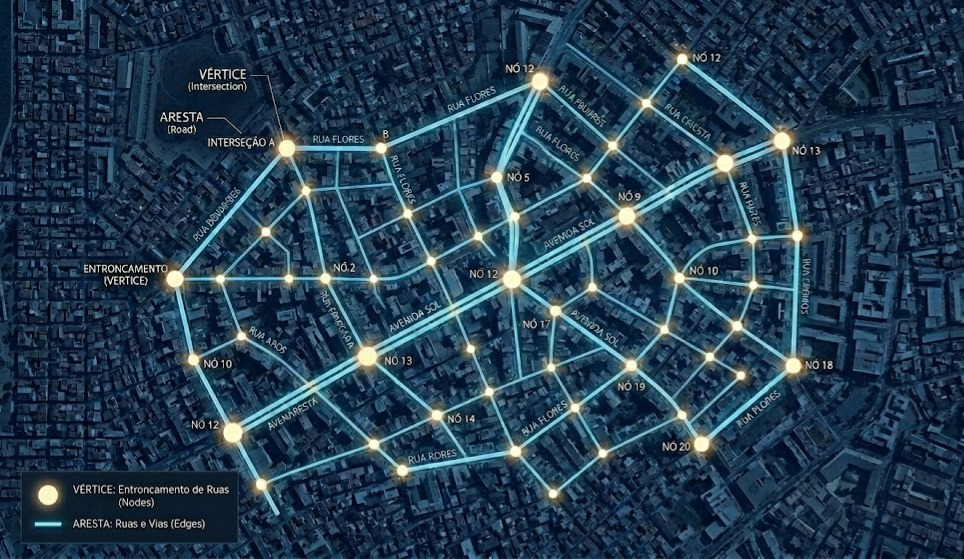

In [ ]:
from IPython.display import IFrame
url_git_raw = "https://raw.githubusercontent.com/talesrios/Arquivos_DOT/main/PDF_MAPA/mapa_10k_CA.pdf"

# 2. Usamos o visualizador do Google
url_final = f"https://docs.google.com/viewer?url={url_git_raw}&embedded=true"

# 3. Exibe o mapa
print("Carregando mapa da Califórnia...")
IFrame(url_final, width=1000, height=700)

Carregando mapa da Califórnia...


In [ ]:
from IPython.display import IFrame

url_git_raw = "https://raw.githubusercontent.com/talesrios/Arquivos_DOT/main/PDF_MAPA/mapa_10k_PA.pdf"

# 2. Usamos o visualizador do Google
url_final = f"https://docs.google.com/viewer?url={url_git_raw}&embedded=true"

# 3. Exibe o mapa
print("Carregando mapa da Califórnia...")
IFrame(url_final, width=1000, height=700)

Carregando mapa da Califórnia...


In [ ]:
from IPython.display import IFrame
url_git_raw = "https://raw.githubusercontent.com/talesrios/Arquivos_DOT/main/PDF_MAPA/mapa_10k_TX.pdf"

# 2. Usamos o visualizador do Google
url_final = f"https://docs.google.com/viewer?url={url_git_raw}&embedded=true"

# 3. Exibe o mapa
print("Carregando mapa da Califórnia...")
IFrame(url_final, width=1000, height=700)

Carregando mapa da Califórnia...


In [ ]:
!pip install powerlaw -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.0/192.0 kB 6.9 MB/s eta 0:00:00


In [ ]:
!wget https://raw.githubusercontent.com/talesrios/Arquivos_DOT/refs/heads/main/mapas_dot/mapa_saida_CA.dot
!wget https://raw.githubusercontent.com/talesrios/Arquivos_DOT/refs/heads/main/mapas_dot/mapa_saida_PA.dot
!wget https://raw.githubusercontent.com/talesrios/Arquivos_DOT/refs/heads/main/mapas_dot/mapa_saida_TX.dot


--2026-03-11 20:49:26--  https://raw.githubusercontent.com/talesrios/Arquivos_DOT/refs/heads/main/mapas_dot/mapa_saida_CA.dot
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 55765588 (53M) [text/plain]
Saving to: ‘mapa_saida_CA.dot.1’

mapa_saida_CA.dot.1 100%[===================>]  53.18M   268MB/s    in 0.2s    

2026-03-11 20:49:26 (268 MB/s) - ‘mapa_saida_CA.dot.1’ saved [55765588/55765588]

--2026-03-11 20:49:26--  https://raw.githubusercontent.com/talesrios/Arquivos_DOT/refs/heads/main/mapas_dot/mapa_saida_PA.dot
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent,

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import matplotlib.ticker as mticker  # necessário para controlar a notação do eixo

def gerar_dashboard(lista_analisadores):

    for g in lista_analisadores:

        degrees = g.degrees

        # ==================================
        # HISTOGRAMA (FREQUÊNCIA ABSOLUTA)
        # ==================================
        degree_count = Counter(degrees)

        graus_all = np.array(sorted(degree_count.keys()))
        freq_all = np.array([degree_count[k] for k in graus_all])

        plt.figure(figsize=(10,6))

        plt.bar(
            graus_all,
            freq_all,
            color='#1f77b4',
            edgecolor='black'
        )

        plt.xlabel("Grau (k)")
        plt.ylabel("Número de Nós")
        plt.title(f"Histograma de Grau - {g.label}")
        plt.ylim(0, max(freq_all) * 1.1)
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        # =======================================
        # Evita notação científica no eixo Y
        # =======================================
        plt.gca().yaxis.set_major_formatter(mticker.ScalarFormatter())
        plt.gca().yaxis.get_major_formatter().set_scientific(False)

        plt.tight_layout()
        plt.show()


        # =====================================
        # DISTRIBUIÇÃO LOG-LOG (PROBABILIDADE)
        # =====================================

        # Probabilidade empírica completa
        pk_all = freq_all / freq_all.sum()

        xmin = g.stats['xmin']
        alpha = g.stats['alpha']

        # Seleciona apenas a cauda (k >= xmin)
        mask_tail = graus_all >= xmin
        graus_tail = graus_all[mask_tail]
        pk_tail = pk_all[mask_tail]

        # Normaliza apenas a cauda para comparar com o modelo
        pk_tail_norm = pk_tail / pk_tail.sum()

        # Curva teórica discreta correta (usando powerlaw)
        k_vals = np.arange(int(xmin), int(max(graus_all)) + 1)
        p_vals = g.fit.power_law.pdf(k_vals)

        plt.figure(figsize=(8,5))

        # Distribuição completa (apenas visualização)
        plt.loglog(graus_all, pk_all, "o",
                   markersize=4,
                   alpha=0.4,
                   label="P(k) completa")

        # Cauda normalizada
        plt.loglog(graus_tail, pk_tail_norm, "o",
                   markersize=6,
                   alpha=0.9,
                   label="Cauda normalizada")

        # Ajuste discreto correto
        plt.loglog(k_vals, p_vals, "--",
                   linewidth=2,
                   label=f"Ajuste discreto (α={alpha:.2f})")

        plt.xlabel("k")
        plt.ylabel("P(k)")
        plt.title(f"Distribuição de Grau (log-log) - {g.label}")
        plt.legend()
        plt.grid(True, which="both", ls="--", alpha=0.4)

        plt.tight_layout()
        plt.show()

In [ ]:
import numpy as np
import powerlaw
import re
import os
from collections import Counter

class AnalisadorGrafos:
    def __init__(self, path, label):
        self.path = path
        self.label = label
        self.degrees = np.array([])
        self.stats = {}
        self._processar()

    def _processar(self):
        if not os.path.exists(self.path):
            print(f"Arquivo nao encontrado: {self.path}")
            return

        # Regex para arestas
        EDGE_RE = re.compile(r'^\s*(".*?"|\S+)\s*(?:--|->)\s*(".*?"|\S+)')
        node_index, next_idx, edges = {}, 0, []

        with open(self.path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line.startswith(("graph", "digraph", "{", "}", "node ", "edge ")) or not line:
                    continue
                m = EDGE_RE.search(line)
                if m:
                    a, b = m.groups()
                    a, b = a.strip('"'), b.strip('"')
                    for node in [a, b]:
                        if node not in node_index:
                            node_index[node] = next_idx
                            next_idx += 1
                    edges.append((node_index[a], node_index[b]))

        if len(edges) == 0: return

        degrees = np.zeros(next_idx, dtype=int)
        for ia, ib in edges:
            degrees[ia] += 1
            degrees[ib] += 1

        self.degrees = degrees[degrees > 0]

        if len(self.degrees) > 0:
            # O ajuste e feito aqui
            self.fit = powerlaw.Fit(self.degrees, discrete=True, verbose=False)

            # Aqui calculamos a comparacao e obtemos R e o p-value da comparacao
            # Usamos a Lognormal como base de comparacao (padrao academico)
            R, p_comparacao = self.fit.distribution_compare('power_law', 'lognormal')
            # R, p_comparacao = self.fit.distribution_compare('lognormal', 'power_law')


            self.stats = {
                'alpha': self.fit.power_law.alpha,
                'xmin': self.fit.power_law.xmin,
                'p_value': p_comparacao, # p-value da comparacao (significancia de R)
                'R_ratio': R,
                'possivel': (R > 0 and p_comparacao < 0.05)
            }

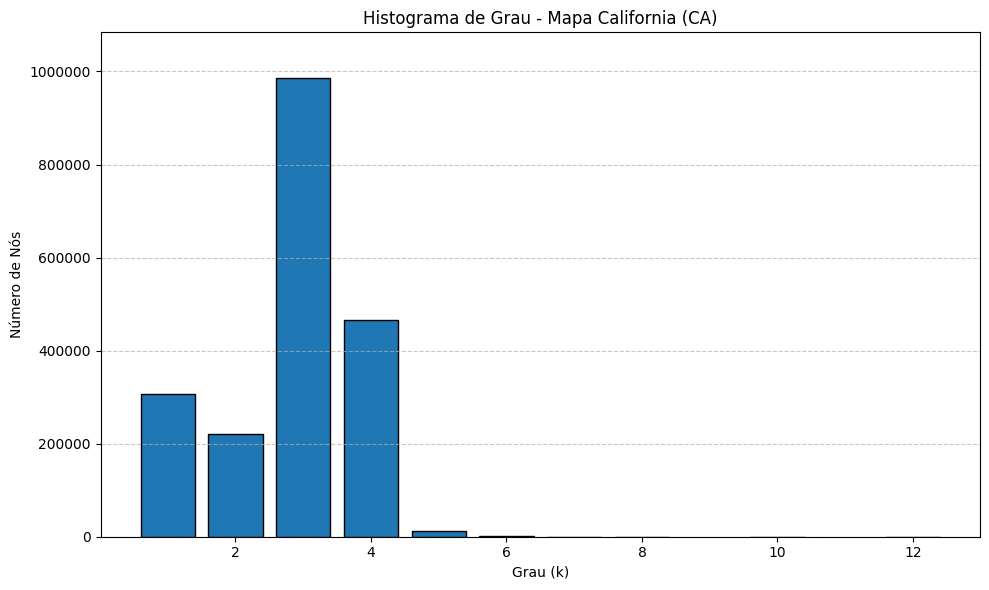

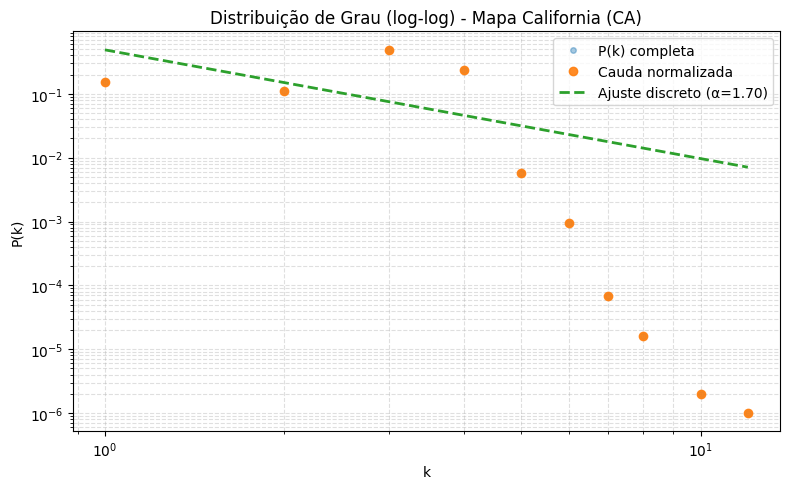


Grafo                     | Alpha   | xmin   | p-value   | R (Ratio) | Power Law?
---------------------------------------------------------------------------------
Mapa California (CA)      | 1.70    | 1      | 0.0000    | -1602418.0004 | Nao


In [ ]:

configuracoes = [
    {"path": "/content/mapa_saida_CA.dot", "label": "Mapa California (CA)"}
]

# 2. Processa os dados
meus_grafos = [AnalisadorGrafos(c['path'], c['label']) for c in configuracoes]

# 3. GERA OS GRÁFICOS
gerar_dashboard(meus_grafos)

# 4. Exibe Tabela de Resultados
header = f"{'Grafo':<25} | {'Alpha':<7} | {'xmin':<6} | {'p-value':<9} | {'R (Ratio)':<9} | {'Power Law?'}"

print("\n" + "=" * len(header))
print(header)
print("-" * len(header))

for g in meus_grafos:
    if g.stats:
        s = g.stats

        # Critério estatístico correto (R > 0 E p < 0.05)
        res = "Sim" if (s['R_ratio'] > 0 and s['p_value'] < 0.05) else "Nao"

        print(f"{g.label:<25} | "
              f"{s['alpha']:<7.2f} | "
              f"{int(s['xmin']):<6} | "
              f"{s['p_value']:<9.4f} | "
              f"{s['R_ratio']:<9.4f} | "
              f"{res}")
    else:
        print(f"{g.label:<25} | Erro no processamento")

print("=" * len(header))

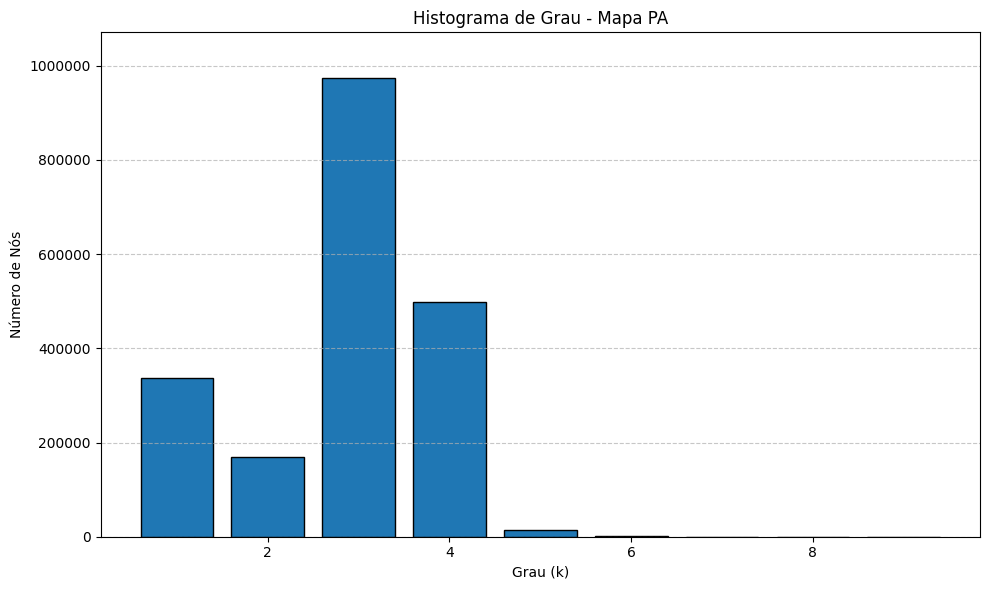

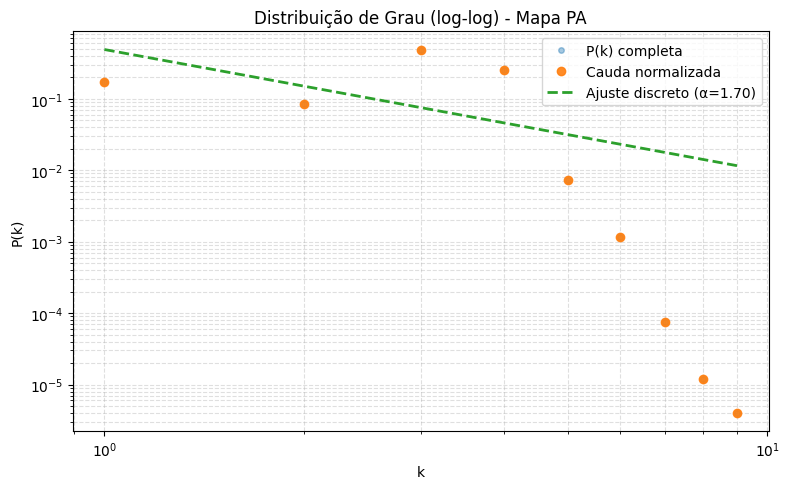


Grafo                     | Alpha   | xmin    | p-value   | R (Ratio) | Power Law?
----------------------------------------------------------------------------------
Mapa PA                   | 1.70    | 1.0     | 0.0000    | -1520334.5337 | Nao


In [ ]:

configuracoes = [
    {"path": "/content/mapa_saida_PA.dot", "label": "Mapa PA"},
]
# 2. Processa os dados
meus_grafos = [AnalisadorGrafos(c['path'], c['label']) for c in configuracoes]

# 3. GERA OS GRÁFICOS (Esta linha faltava!)
gerar_dashboard(meus_grafos)

# 4. Exibe Tabela de Resultados
header = f"{'Grafo':<25} | {'Alpha':<7} | {'xmin':<7} | {'p-value':<9} | {'R (Ratio)':<9} | {'Power Law?'}"
print("\n" + "=" * len(header))
print(header)
print("-" * len(header))

for g in meus_grafos:
    if g.stats:
        s = g.stats
        # Critério acadêmico: R positivo indica tendência à Lei de Potência
        res = "Sim" if s['R_ratio'] > 0 else "Nao"
        print(f"{g.label:<25} | {s['alpha']:<7.2f} | {s['xmin']:<7.1f} | {s['p_value']:<9.4f} | {s['R_ratio']:<9.4f} | {res}")
    else:
        print(f"{g.label:<25} | Erro no processamento")

print("=" * len(header))

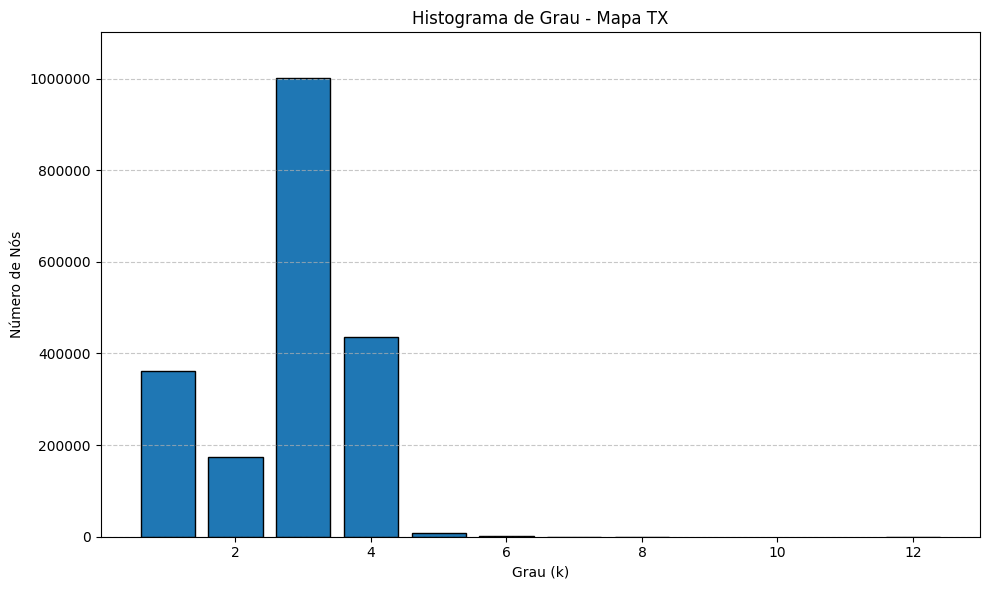

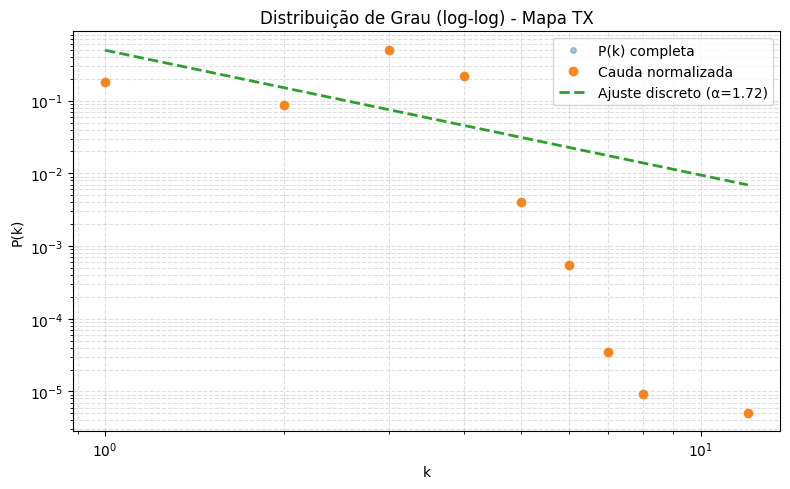


Grafo                     | Alpha   | xmin    | p-value   | R (Ratio) | Power Law?
----------------------------------------------------------------------------------
Mapa TX                   | 1.72    | 1.0     | 0.0000    | -1444708.5973 | Nao


In [ ]:

configuracoes = [
    {"path": "/content/mapa_saida_TX.dot", "label": "Mapa TX"}
]

# 2. Processa os dados
meus_grafos = [AnalisadorGrafos(c['path'], c['label']) for c in configuracoes]

# 3. GERA OS GRÁFICOS (Esta linha faltava!)
gerar_dashboard(meus_grafos)

# 4. Exibe Tabela de Resultados
header = f"{'Grafo':<25} | {'Alpha':<7} | {'xmin':<7} | {'p-value':<9} | {'R (Ratio)':<9} | {'Power Law?'}"
print("\n" + "=" * len(header))
print(header)
print("-" * len(header))

for g in meus_grafos:
    if g.stats:
        s = g.stats
        # Critério acadêmico: R positivo indica tendência à Lei de Potência
        res = "Sim" if s['R_ratio'] > 0 else "Nao"
        print(f"{g.label:<25} | {s['alpha']:<7.2f} | {s['xmin']:<7.1f} | {s['p_value']:<9.4f} | {s['R_ratio']:<9.4f} | {res}")
    else:
        print(f"{g.label:<25} | Erro no processamento")

print("=" * len(header))